In [2]:
import os

dataset_path = "/kaggle/input/datasets/dhanushreerajangam/acrima-images-zip/Database/Images"

images = os.listdir(dataset_path)

print("Total images:", len(images))
print("First 10 images:")
print(images[:10])

Total images: 705
First 10 images:
['Im332_g_ACRIMA.jpg', 'Im414_g_ACRIMA.jpg', 'Im268_ACRIMA.jpg', 'Im280_ACRIMA.jpg', 'Im213_ACRIMA.jpg', 'Im194_ACRIMA.jpg', 'Im098_ACRIMA.jpg', 'Im463_g_ACRIMA.jpg', 'Im673_g_ACRIMA.jpg', 'Im600_g_ACRIMA.jpg']


In [3]:
!pip install -q timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os
import numpy as np

In [4]:
class ACRIMADataset(Dataset):

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.images = []
        self.labels = []

        for file in os.listdir(root_dir):

            if file.lower().endswith((".jpg", ".jpeg", ".png")):

                self.images.append(file)

                # _g_ means glaucoma = 1
                if "_g_" in file:
                    self.labels.append(1)
                else:
                    self.labels.append(0)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        image_name = self.images[index]
        image_path = os.path.join(self.root_dir, image_name)

        image = Image.open(image_path).convert("RGB")
        label = self.labels[index]

        if self.transform:
            image = self.transform(image)

        return image, label

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [7]:
num_epochs = 20
patience = 3

best_val_loss = float("inf")
patience_counter = 0

best_model_path = "/kaggle/working/best_convnext_fusion_regularized.pth"

print("Maximum epochs:", num_epochs)
print("Early stopping patience:", patience)

Maximum epochs: 20
Early stopping patience: 3


In [ ]:
CONVNEXT-TINY + MLFF

In [8]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transform loaded successfully!")

Transform loaded successfully!


In [9]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# Create ConvNeXt 80/20 dataset
convnext8020_dataset = ACRIMADataset(
    dataset_path,
    transform=transform
)

indices = np.arange(len(convnext8020_dataset))
labels = np.array(convnext8020_dataset.labels)

convnext8020_train_indices, convnext8020_val_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

print("Total:", len(indices))
print("Training:", len(convnext8020_train_indices))
print("Validation:", len(convnext8020_val_indices))

Total: 705
Training: 564
Validation: 141


In [10]:
convnext8020_train_dataset = Subset(
    convnext8020_dataset,
    convnext8020_train_indices
)

convnext8020_val_dataset = Subset(
    convnext8020_dataset,
    convnext8020_val_indices
)

print("Training:", len(convnext8020_train_dataset))
print("Validation:", len(convnext8020_val_dataset))

Training: 564
Validation: 141


In [11]:
convnext8020_train_loader = DataLoader(
    convnext8020_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

convnext8020_val_loader = DataLoader(
    convnext8020_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training batches:", len(convnext8020_train_loader))
print("Validation batches:", len(convnext8020_val_loader))

Training batches: 18
Validation batches: 5


In [20]:
class ConvNeXt8020Fusion(nn.Module):

    def __init__(self, num_classes=2):
        super().__init__()

        self.backbone = timm.create_model(
            "convnext_tiny",
            pretrained=False,
            features_only=True,
            out_indices=(1, 2, 3)
        )

        channels = self.backbone.feature_info.channels()

        print("Feature channels:", channels)

        self.conv1 = nn.Conv2d(
            channels[0], 128, kernel_size=1
        )

        self.conv2 = nn.Conv2d(
            channels[1], 128, kernel_size=1
        )

        self.conv3 = nn.Conv2d(
            channels[2], 128, kernel_size=1
        )

        self.fusion = nn.Sequential(
            nn.Conv2d(
                128 * 3,
                256,
                kernel_size=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        features = self.backbone(x)

        f1 = self.conv1(features[0])
        f2 = self.conv2(features[1])
        f3 = self.conv3(features[2])

        target_size = f3.shape[2:]

        f1 = F.interpolate(
            f1,
            size=target_size,
            mode="bilinear",
            align_corners=False
        )

        f2 = F.interpolate(
            f2,
            size=target_size,
            mode="bilinear",
            align_corners=False
        )

        fused = torch.cat(
            [f1, f2, f3],
            dim=1
        )

        fused = self.fusion(fused)

        fused = F.adaptive_avg_pool2d(
            fused,
            1
        )

        fused = torch.flatten(
            fused,
            1
        )

        return self.classifier(fused)

In [21]:
import timm
convnext8020_model = ConvNeXt8020Fusion().to(device)

print("80/20 ConvNeXt model created.")

Feature channels: [192, 384, 768]
80/20 ConvNeXt model created.


In [22]:
convnext8020_model = ConvNeXt8020Fusion().to(device)

print("80/20 ConvNeXt model created.")
convnext8020_criterion = nn.CrossEntropyLoss()

convnext8020_optimizer = torch.optim.AdamW(
    convnext8020_model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

convnext8020_epochs = 20
convnext8020_patience = 3

convnext8020_best_loss = float("inf")
convnext8020_patience_count = 0

convnext8020_best_path = (
    "/kaggle/working/best_convnext_8020.pth"
)

print("Training setup ready.")

Feature channels: [192, 384, 768]
80/20 ConvNeXt model created.
Training setup ready.


In [23]:
for epoch in range(convnext8020_epochs):

    convnext8020_model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in convnext8020_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        convnext8020_optimizer.zero_grad()

        outputs = convnext8020_model(images)

        loss = convnext8020_criterion(
            outputs,
            labels
        )

        loss.backward()
        convnext8020_optimizer.step()

        train_loss += loss.item()

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        train_total += labels.size(0)

        train_correct += (
            predictions == labels
        ).sum().item()

    train_accuracy = (
        100 * train_correct / train_total
    )

    # Validation
    convnext8020_model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in convnext8020_val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = convnext8020_model(images)

            loss = convnext8020_criterion(
                outputs,
                labels
            )

            val_loss += loss.item()

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_total += labels.size(0)

            val_correct += (
                predictions == labels
            ).sum().item()

    train_loss /= len(convnext8020_train_loader)
    val_loss /= len(convnext8020_val_loader)

    val_accuracy = (
        100 * val_correct / val_total
    )

    print(
        f"Epoch [{epoch+1}/{convnext8020_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

    if val_loss < convnext8020_best_loss:

        convnext8020_best_loss = val_loss
        convnext8020_patience_count = 0

        torch.save(
            convnext8020_model.state_dict(),
            convnext8020_best_path
        )

        print("Best model saved.")

    else:
        convnext8020_patience_count += 1

    if convnext8020_patience_count >= convnext8020_patience:

        print("Early stopping.")
        break

Epoch [1/20] Train Loss: 0.4359 Train Acc: 78.72% Val Loss: 0.4436 Val Acc: 80.14%
Best model saved.
Epoch [2/20] Train Loss: 0.3224 Train Acc: 86.35% Val Loss: 0.2853 Val Acc: 85.82%
Best model saved.
Epoch [3/20] Train Loss: 0.3061 Train Acc: 86.17% Val Loss: 0.2679 Val Acc: 86.52%
Best model saved.
Epoch [4/20] Train Loss: 0.2886 Train Acc: 86.17% Val Loss: 0.2545 Val Acc: 87.23%
Best model saved.
Epoch [5/20] Train Loss: 0.2764 Train Acc: 86.88% Val Loss: 0.1923 Val Acc: 88.65%
Best model saved.
Epoch [6/20] Train Loss: 0.2516 Train Acc: 90.43% Val Loss: 0.1806 Val Acc: 90.78%
Best model saved.
Epoch [7/20] Train Loss: 0.2404 Train Acc: 90.78% Val Loss: 0.1852 Val Acc: 91.49%
Epoch [8/20] Train Loss: 0.2105 Train Acc: 92.91% Val Loss: 0.1925 Val Acc: 92.91%
Epoch [9/20] Train Loss: 0.1910 Train Acc: 93.97% Val Loss: 0.1432 Val Acc: 92.20%
Best model saved.
Epoch [10/20] Train Loss: 0.1821 Train Acc: 93.09% Val Loss: 0.1578 Val Acc: 92.91%
Epoch [11/20] Train Loss: 0.1515 Train Acc:

In [26]:
convnext8020_model.load_state_dict(
    torch.load(
        convnext8020_best_path,
        map_location=device
    )
)

convnext8020_model.eval()

print("Best 80/20 ConvNeXt model loaded.")

Best 80/20 ConvNeXt model loaded.


In [27]:
from sklearn.metrics import confusion_matrix

convnext8020_actual = []
convnext8020_predicted = []

with torch.no_grad():

    for images, labels in convnext8020_val_loader:

        images = images.to(device)

        outputs = convnext8020_model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        convnext8020_actual.extend(
            labels.numpy()
        )

        convnext8020_predicted.extend(
            predictions.cpu().numpy()
        )

convnext8020_cm = confusion_matrix(
    convnext8020_actual,
    convnext8020_predicted
)

print("ConvNeXt 80/20 Confusion Matrix:")
print(convnext8020_cm)

correct = sum(
    a == p
    for a, p in zip(
        convnext8020_actual,
        convnext8020_predicted
    )
)

print("\nCorrect:", correct)
print("Total:", len(convnext8020_actual))

ConvNeXt 80/20 Confusion Matrix:
[[55  7]
 [ 5 74]]

Correct: 129
Total: 141


In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

tn, fp, fn, tp = convnext8020_cm.ravel()

accuracy = accuracy_score(
    convnext8020_actual,
    convnext8020_predicted
)

sensitivity = tp / (tp + fn)

specificity = tn / (tn + fp)

precision = precision_score(
    convnext8020_actual,
    convnext8020_predicted,
    zero_division=0
)

f1 = f1_score(
    convnext8020_actual,
    convnext8020_predicted,
    zero_division=0
)

print(f"Accuracy    : {accuracy * 100:.2f}%")
print(f"Sensitivity : {sensitivity * 100:.2f}%")
print(f"Specificity : {specificity * 100:.2f}%")
print(f"Precision   : {precision * 100:.2f}%")
print(f"Recall      : {sensitivity * 100:.2f}%")
print(f"F1-Score    : {f1 * 100:.2f}%")

Accuracy    : 91.49%
Sensitivity : 93.67%
Specificity : 88.71%
Precision   : 91.36%
Recall      : 93.67%
F1-Score    : 92.50%


In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class ConvNeXt8020Fusion(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.backbone = timm.create_model(
            "convnext_tiny",
            pretrained=False,
            features_only=True,
            out_indices=(1, 2, 3)
        )

        channels = self.backbone.feature_info.channels()

        self.conv1 = nn.Conv2d(channels[0], 128, 1)
        self.conv2 = nn.Conv2d(channels[1], 128, 1)
        self.conv3 = nn.Conv2d(channels[2], 128, 1)

        self.fusion = nn.Sequential(
            nn.Conv2d(384, 256, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)

        f1 = self.conv1(features[0])
        f2 = self.conv2(features[1])
        f3 = self.conv3(features[2])

        target_size = f3.shape[2:]

        f1 = F.interpolate(f1, size=target_size,
                           mode="bilinear", align_corners=False)
        f2 = F.interpolate(f2, size=target_size,
                           mode="bilinear", align_corners=False)

        fused = torch.cat([f1, f2, f3], dim=1)
        fused = self.fusion(fused)

        fused = F.adaptive_avg_pool2d(fused, 1)
        fused = torch.flatten(fused, 1)

        return self.classifier(fused)


convnext_model = ConvNeXt8020Fusion().to(device)

convnext_model.load_state_dict(
    torch.load(
        "/kaggle/working/best_convnext_8020.pth",
        map_location=device
    )
)

convnext_model.eval()

convnext8020_true_labels = []
convnext8020_predictions = []

with torch.no_grad():
    for images, labels in convnext8020_val_loader:

        images = images.to(device)

        outputs = convnext_model(images)
        predictions = torch.argmax(outputs, dim=1)

        convnext8020_true_labels.extend(labels.numpy())
        convnext8020_predictions.extend(
            predictions.cpu().numpy()
        )

print("Predictions generated successfully!")

Predictions generated successfully!


Confusion Matrix:
[[55  7]
 [ 5 74]]


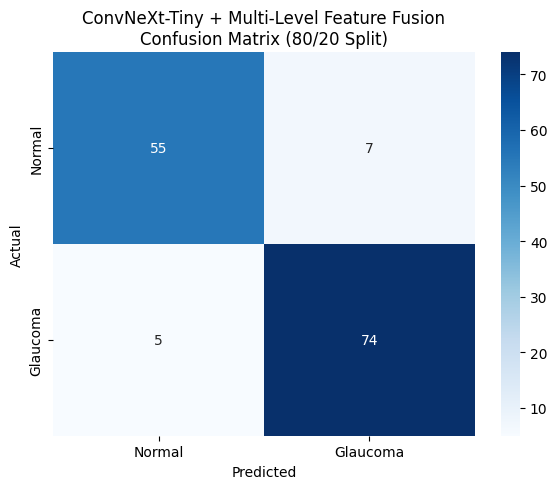

In [30]:
cm = confusion_matrix(
    convnext8020_true_labels,
    convnext8020_predictions
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Glaucoma"],
    yticklabels=["Normal", "Glaucoma"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    "ConvNeXt-Tiny + Multi-Level Feature Fusion\n"
    "Confusion Matrix (80/20 Split)"
)

plt.tight_layout()
plt.show()

In [32]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

convnext8020_model.eval()

# Take one image from validation set
image, label = convnext8020_val_dataset[0]
image_input = image.unsqueeze(0).to(device)

with torch.no_grad():

    # Extract ConvNeXt feature levels
    features = convnext8020_model.backbone(image_input)

    # Project each feature level
    f1 = convnext8020_model.conv1(features[0])
    f2 = convnext8020_model.conv2(features[1])
    f3 = convnext8020_model.conv3(features[2])

    # Resize to deepest feature-map size
    target_size = f3.shape[2:]

    f1 = F.interpolate(
        f1, size=target_size,
        mode="bilinear",
        align_corners=False
    )

    f2 = F.interpolate(
        f2, size=target_size,
        mode="bilinear",
        align_corners=False
    )

    # MLFF fusion
    fused = torch.cat([f1, f2, f3], dim=1)
    fused = convnext8020_model.fusion(fused)

# Calculate quantitative statistics
feature_maps = {
    "Level 1": f1,
    "Level 2": f2,
    "Level 3": f3,
    "Fused MLFF": fused
}

results = []

for name, feature in feature_maps.items():

    activation = feature.abs()

    mean_activation = activation.mean().item()
    std_activation = activation.std().item()
    max_activation = activation.max().item()

    threshold = activation.mean()
    active_percentage = (
        (activation > threshold).float().mean().item() * 100
    )

    results.append([
        name,
        mean_activation,
        std_activation,
        max_activation,
        active_percentage
    ])

print("\nQuantitative Feature Analysis")
print("-" * 75)
print(
    f"{'Feature':<15}"
    f"{'Mean':<12}"
    f"{'Std':<12}"
    f"{'Max':<12}"
    f"{'Active %':<12}"
)
print("-" * 75)

for row in results:
    print(
        f"{row[0]:<15}"
        f"{row[1]:<12.4f}"
        f"{row[2]:<12.4f}"
        f"{row[3]:<12.4f}"
        f"{row[4]:<12.2f}"
    )


Quantitative Feature Analysis
---------------------------------------------------------------------------
Feature        Mean        Std         Max         Active %    
---------------------------------------------------------------------------
Level 1        0.1678      0.1135      0.7457      45.11       
Level 2        0.2903      0.2407      1.7948      41.33       
Level 3        0.7409      0.6362      3.9673      38.58       
Fused MLFF     0.2761      0.4333      2.5242      32.41       


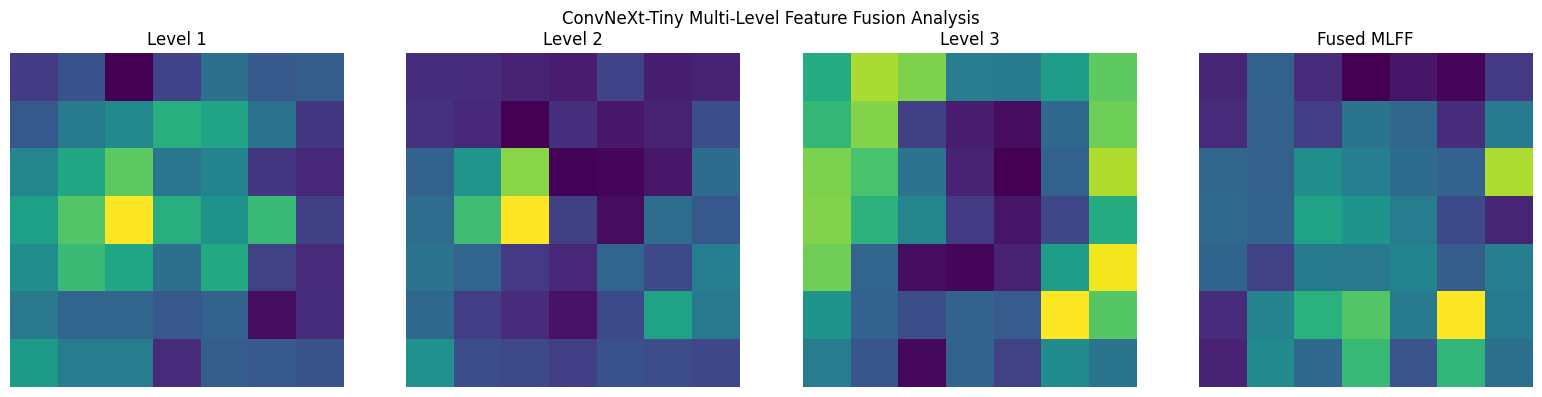

In [53]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, feature) in zip(axes, feature_maps.items()):

    # Average across channels
    activation_map = feature[0].abs().mean(dim=0).cpu().numpy()

    ax.imshow(activation_map, cmap="viridis")
    ax.set_title(name)
    ax.axis("off")

plt.suptitle("ConvNeXt-Tiny Multi-Level Feature Fusion Analysis")
plt.tight_layout()
plt.show()

In [ ]:
MAXVIT-TINY + MLFF

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import timm

from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [34]:
maxvit8020_path = "/kaggle/input/datasets/dhanushreerajangam/acrima-images-zip/Database/Images"

print("Total images:", len(os.listdir(maxvit8020_path)))

Total images: 705


In [38]:
maxvit8020_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [39]:
class MaxViT8020Dataset(Dataset):

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.images = []
        self.labels = []

        for file in os.listdir(root_dir):

            if file.lower().endswith((".jpg", ".jpeg", ".png")):

                self.images.append(file)

                if "_g_" in file:
                    self.labels.append(1)
                else:
                    self.labels.append(0)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        image_path = os.path.join(
            self.root_dir,
            self.images[index]
        )

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, self.labels[index]

In [40]:
from sklearn.model_selection import train_test_split

maxvit8020_dataset = MaxViT8020Dataset(
    maxvit8020_path,
    transform=maxvit8020_transform
)

indices = np.arange(len(maxvit8020_dataset))
labels = np.array(maxvit8020_dataset.labels)

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

print("Total:", len(indices))
print("Training:", len(train_indices))
print("Validation:", len(val_indices))

Total: 705
Training: 564
Validation: 141


In [41]:
from torch.utils.data import Subset

maxvit8020_train_dataset = Subset(
    maxvit8020_dataset,
    train_indices
)

maxvit8020_val_dataset = Subset(
    maxvit8020_dataset,
    val_indices
)

print("Training images:", len(maxvit8020_train_dataset))
print("Validation images:", len(maxvit8020_val_dataset))

Training images: 564
Validation images: 141


In [42]:
maxvit8020_train_loader = DataLoader(
    maxvit8020_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

maxvit8020_val_loader = DataLoader(
    maxvit8020_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training batches:", len(maxvit8020_train_loader))
print("Validation batches:", len(maxvit8020_val_loader))

Training batches: 18
Validation batches: 5


In [43]:
class MaxViT8020Fusion(nn.Module):

    def __init__(self, num_classes=2):
        super().__init__()

        self.backbone = timm.create_model(
            "maxvit_tiny_tf_224",
            pretrained=False,
            features_only=True,
            out_indices=(1, 2, 3)
        )

        channels = self.backbone.feature_info.channels()

        print("Feature channels:", channels)

        self.conv1 = nn.Conv2d(
            channels[0], 128, kernel_size=1
        )

        self.conv2 = nn.Conv2d(
            channels[1], 128, kernel_size=1
        )

        self.conv3 = nn.Conv2d(
            channels[2], 128, kernel_size=1
        )

        self.fusion = nn.Sequential(
            nn.Conv2d(
                128 * 3,
                256,
                kernel_size=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        features = self.backbone(x)

        f1 = self.conv1(features[0])
        f2 = self.conv2(features[1])
        f3 = self.conv3(features[2])

        target_size = f3.shape[2:]

        f1 = F.interpolate(
            f1,
            size=target_size,
            mode="bilinear",
            align_corners=False
        )

        f2 = F.interpolate(
            f2,
            size=target_size,
            mode="bilinear",
            align_corners=False
        )

        fused = torch.cat(
            [f1, f2, f3],
            dim=1
        )

        fused = self.fusion(fused)

        fused = F.adaptive_avg_pool2d(
            fused,
            1
        )

        fused = torch.flatten(
            fused,
            1
        )

        return self.classifier(fused)

In [44]:
maxvit8020_model = MaxViT8020Fusion().to(device)

print("80/20 MaxViT model created.")

Feature channels: [64, 128, 256]
80/20 MaxViT model created.


In [45]:
maxvit8020_criterion = nn.CrossEntropyLoss()

maxvit8020_optimizer = torch.optim.AdamW(
    maxvit8020_model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

maxvit8020_epochs = 20
maxvit8020_patience = 3

maxvit8020_best_loss = float("inf")
maxvit8020_patience_count = 0

maxvit8020_best_path = (
    "/kaggle/working/best_maxvit_8020.pth"
)

print("Training setup ready.")

Training setup ready.


In [94]:
for epoch in range(maxvit8020_epochs):

    maxvit8020_model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in maxvit8020_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        maxvit8020_optimizer.zero_grad()

        outputs = maxvit8020_model(images)

        loss = maxvit8020_criterion(
            outputs,
            labels
        )

        loss.backward()
        maxvit8020_optimizer.step()

        train_loss += loss.item()

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        train_total += labels.size(0)

        train_correct += (
            predictions == labels
        ).sum().item()

    train_accuracy = (
        100 * train_correct / train_total
    )

    # Validation
    maxvit8020_model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in maxvit8020_val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = maxvit8020_model(images)

            loss = maxvit8020_criterion(
                outputs,
                labels
            )

            val_loss += loss.item()

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_total += labels.size(0)

            val_correct += (
                predictions == labels
            ).sum().item()

    train_loss /= len(maxvit8020_train_loader)
    val_loss /= len(maxvit8020_val_loader)

    val_accuracy = (
        100 * val_correct / val_total
    )

    print(
        f"Epoch [{epoch+1}/{maxvit8020_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

    if val_loss < maxvit8020_best_loss:

        maxvit8020_best_loss = val_loss
        maxvit8020_patience_count = 0

        torch.save(
            maxvit8020_model.state_dict(),
            maxvit8020_best_path
        )

        print("Best model saved.")

    else:

        maxvit8020_patience_count += 1

    if maxvit8020_patience_count >= maxvit8020_patience:

        print("Early stopping.")
        break

Epoch [1/20] Train Loss: 0.1064 Train Acc: 96.45% Val Loss: 0.0537 Val Acc: 97.87%
Early stopping.


In [89]:
maxvit8020_model.load_state_dict(
    torch.load(
        maxvit8020_best_path,
        map_location=device
    )
)

maxvit8020_model.eval()

print("Best 80/20 MaxViT model loaded.")

Best 80/20 MaxViT model loaded.


In [90]:
from sklearn.metrics import confusion_matrix

maxvit8020_actual = []
maxvit8020_predicted = []

with torch.no_grad():

    for images, labels in maxvit8020_val_loader:

        images = images.to(device)

        outputs = maxvit8020_model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        maxvit8020_actual.extend(
            labels.numpy()
        )

        maxvit8020_predicted.extend(
            predictions.cpu().numpy()
        )

maxvit8020_cm = confusion_matrix(
    maxvit8020_actual,
    maxvit8020_predicted
)

print("MaxViT 80/20 Confusion Matrix:")
print(maxvit8020_cm)

print("\nCorrect predictions:",
      sum(
          a == p
          for a, p in zip(
              maxvit8020_actual,
              maxvit8020_predicted
          )
      ))

print("Total validation images:",
      len(maxvit8020_actual))

MaxViT 80/20 Confusion Matrix:
[[62  0]
 [ 1 78]]

Correct predictions: 140
Total validation images: 141


In [95]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

tn, fp, fn, tp = maxvit8020_cm.ravel()

accuracy = accuracy_score(
    maxvit8020_actual,
    maxvit8020_predicted
)

sensitivity = tp / (tp + fn)

specificity = tn / (tn + fp)

precision = precision_score(
    maxvit8020_actual,
    maxvit8020_predicted,
    zero_division=0
)

f1 = f1_score(
    maxvit8020_actual,
    maxvit8020_predicted,
    zero_division=0
)

print(f"Accuracy    : {accuracy * 100:.2f}%")
print(f"Sensitivity : {sensitivity * 100:.2f}%")
print(f"Specificity : {specificity * 100:.2f}%")
print(f"Precision   : {precision * 100:.2f}%")
print(f"Recall      : {sensitivity * 100:.2f}%")
print(f"F1-Score    : {f1 * 100:.2f}%")

Accuracy    : 99.29%
Sensitivity : 98.73%
Specificity : 100.00%
Precision   : 100.00%
Recall      : 98.73%
F1-Score    : 99.36%


In [96]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

# Recreate MaxViT model architecture
class MaxViT8020Fusion(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.backbone = timm.create_model(
            "maxvit_tiny_tf_224",
            pretrained=False,
            features_only=True,
            out_indices=(1, 2, 3)
        )

        channels = self.backbone.feature_info.channels()

        self.conv1 = nn.Conv2d(channels[0], 128, kernel_size=1)
        self.conv2 = nn.Conv2d(channels[1], 128, kernel_size=1)
        self.conv3 = nn.Conv2d(channels[2], 128, kernel_size=1)

        self.fusion = nn.Sequential(
            nn.Conv2d(384, 256, kernel_size=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)

        f1 = self.conv1(features[0])
        f2 = self.conv2(features[1])
        f3 = self.conv3(features[2])

        target_size = f3.shape[2:]

        f1 = F.interpolate(
            f1, size=target_size,
            mode="bilinear",
            align_corners=False
        )

        f2 = F.interpolate(
            f2, size=target_size,
            mode="bilinear",
            align_corners=False
        )

        fused = torch.cat([f1, f2, f3], dim=1)

        fused = self.fusion(fused)

        fused = F.adaptive_avg_pool2d(fused, 1)
        fused = torch.flatten(fused, 1)

        return self.classifier(fused)


# Create model
maxvit_model = MaxViT8020Fusion().to(device)

# Load trained weights
maxvit_model.load_state_dict(
    torch.load(
        "/kaggle/working/best_maxvit_8020.pth",
        map_location=device
    )
)

maxvit_model.eval()

print("MaxViT model loaded successfully!")

MaxViT model loaded successfully!


Confusion Matrix:
[[62  0]
 [ 1 78]]


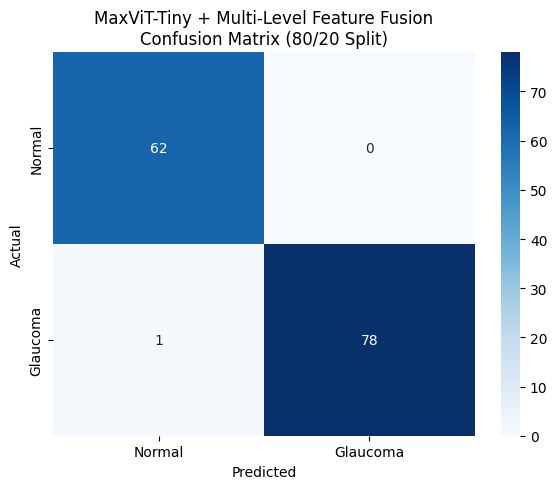

In [97]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

maxvit8020_true_labels = []
maxvit8020_predictions = []

with torch.no_grad():

    for images, labels in maxvit8020_val_loader:

        images = images.to(device)

        outputs = maxvit_model(images)

        predictions = torch.argmax(outputs, dim=1)

        maxvit8020_true_labels.extend(
            labels.numpy()
        )

        maxvit8020_predictions.extend(
            predictions.cpu().numpy()
        )


cm = confusion_matrix(
    maxvit8020_true_labels,
    maxvit8020_predictions
)

print("Confusion Matrix:")
print(cm)


plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Glaucoma"],
    yticklabels=["Normal", "Glaucoma"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "MaxViT-Tiny + Multi-Level Feature Fusion\n"
    "Confusion Matrix (80/20 Split)"
)

plt.tight_layout()
plt.show()

In [98]:
import torch
import torch.nn.functional as F

maxvit8020_model.eval()

# Take one validation image
image, label = maxvit8020_val_dataset[0]
image_input = image.unsqueeze(0).to(device)

with torch.no_grad():

    # Extract MaxViT feature levels
    features = maxvit8020_model.backbone(image_input)

    f1 = maxvit8020_model.conv1(features[0])
    f2 = maxvit8020_model.conv2(features[1])
    f3 = maxvit8020_model.conv3(features[2])

    # Resize to deepest feature-map size
    target_size = f3.shape[2:]

    f1 = F.interpolate(
        f1,
        size=target_size,
        mode="bilinear",
        align_corners=False
    )

    f2 = F.interpolate(
        f2,
        size=target_size,
        mode="bilinear",
        align_corners=False
    )

    # MLFF fusion
    fused = torch.cat([f1, f2, f3], dim=1)
    fused = maxvit8020_model.fusion(fused)


# Quantitative analysis
feature_maps = {
    "Level 1": f1,
    "Level 2": f2,
    "Level 3": f3,
    "Fused MLFF": fused
}

print("\nMaxViT-Tiny + MLFF Quantitative Feature Analysis")
print("-" * 75)
print(
    f"{'Feature':<15}"
    f"{'Mean':<12}"
    f"{'Std':<12}"
    f"{'Max':<12}"
    f"{'Active %':<12}"
)
print("-" * 75)

for name, feature in feature_maps.items():

    activation = feature.abs()

    mean_activation = activation.mean().item()
    std_activation = activation.std().item()
    max_activation = activation.max().item()

    threshold = activation.mean()

    active_percentage = (
        (activation > threshold).float().mean().item() * 100
    )

    print(
        f"{name:<15}"
        f"{mean_activation:<12.4f}"
        f"{std_activation:<12.4f}"
        f"{max_activation:<12.4f}"
        f"{active_percentage:<12.2f}"
    )


MaxViT-Tiny + MLFF Quantitative Feature Analysis
---------------------------------------------------------------------------
Feature        Mean        Std         Max         Active %    
---------------------------------------------------------------------------
Level 1        0.9417      0.7107      5.2589      42.37       
Level 2        1.1298      0.8642      5.4454      41.38       
Level 3        2.4984      2.0416      14.5331     41.04       
Fused MLFF     0.2680      0.4114      3.7172      33.66       


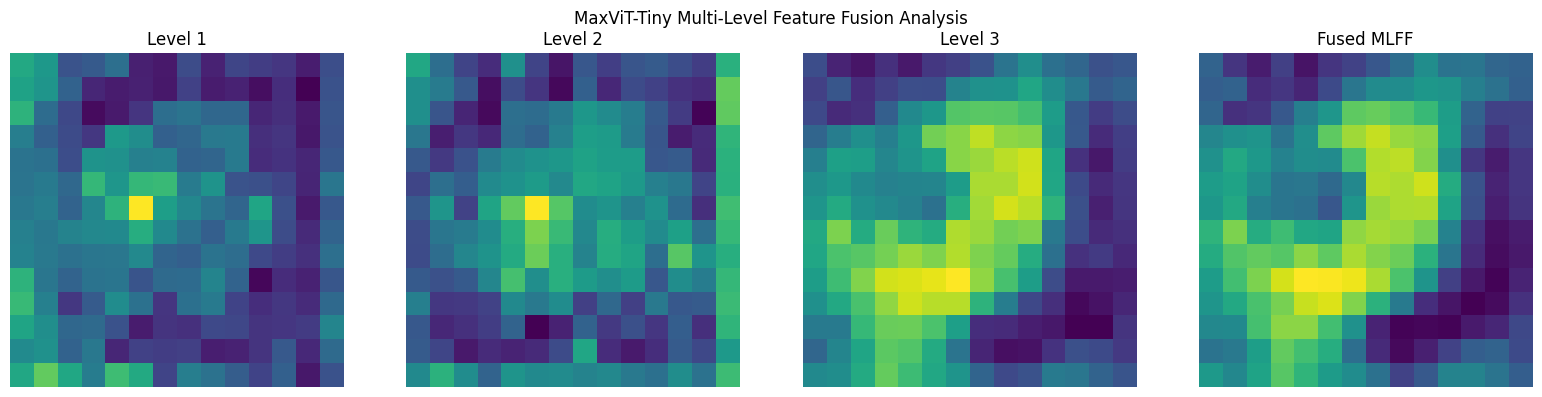

In [59]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, feature) in zip(axes, feature_maps.items()):

    activation_map = feature[0].abs().mean(dim=0).cpu().numpy()

    ax.imshow(activation_map, cmap="viridis")
    ax.set_title(name)
    ax.axis("off")

plt.suptitle("MaxViT-Tiny Multi-Level Feature Fusion Analysis")
plt.tight_layout()
plt.show()

In [ ]:
SWIN TRANSFORMER + MLFF

In [60]:
!pip install -q timm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import timm

from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import os
import numpy as np
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [61]:
swin8020_path = "/kaggle/input/datasets/dhanushreerajangam/acrima-images-zip/Database/Images"

class ACRIMADataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.images = []
        self.labels = []

        for file in os.listdir(root_dir):
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                self.images.append(file)

                if "_g_" in file.lower():
                    self.labels.append(1)
                else:
                    self.labels.append(0)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        path = os.path.join(self.root_dir, self.images[idx])
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, self.labels[idx]


swin8020_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

swin8020_dataset = ACRIMADataset(
    swin8020_path,
    transform=swin8020_transform
)

print("Total images:", len(swin8020_dataset))

swin8020_indices = np.arange(len(swin8020_dataset))
swin8020_labels = np.array(swin8020_dataset.labels)

swin8020_train_indices, swin8020_val_indices = train_test_split(
    swin8020_indices,
    test_size=0.20,
    random_state=42,
    stratify=swin8020_labels
)

print("Training images:", len(swin8020_train_indices))
print("Validation images:", len(swin8020_val_indices))

Total images: 705
Training images: 564
Validation images: 141


In [62]:
swin8020_backbone = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=False,
    features_only=True,
    out_indices=(1, 2, 3)
)

print(swin8020_backbone)
print("Feature channels:", swin8020_backbone.feature_info.channels())

FeatureListNet(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers_0): SwinTransformerStage(
    (downsample): Identity()
    (blocks): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): WindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=96, out_features=96, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
          (softmax): Softmax(dim=-1)
        )
        (drop_path1): Identity()
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=96, out_features=384, bias=True)
          (act): GELU(approximate='none')
          (drop1): Dropout(p=0.0, inplace=False)
          (norm): Identi

In [65]:
class Swin8020Fusion(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.backbone = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=False,
            features_only=True,
            out_indices=(1, 2, 3)
        )

        self.conv1 = nn.Conv2d(192, 128, 1)
        self.conv2 = nn.Conv2d(384, 128, 1)
        self.conv3 = nn.Conv2d(768, 128, 1)

        self.fusion = nn.Sequential(
            nn.Conv2d(384, 256, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)

        # Swin outputs NHWC -> convert to NCHW
        f1 = features[0].permute(0, 3, 1, 2)
        f2 = features[1].permute(0, 3, 1, 2)
        f3 = features[2].permute(0, 3, 1, 2)

        f1 = self.conv1(f1)
        f2 = self.conv2(f2)
        f3 = self.conv3(f3)

        target_size = f3.shape[2:]

        f1 = F.interpolate(
            f1,
            size=target_size,
            mode="bilinear",
            align_corners=False
        )

        f2 = F.interpolate(
            f2,
            size=target_size,
            mode="bilinear",
            align_corners=False
        )

        fused = torch.cat([f1, f2, f3], dim=1)

        fused = self.fusion(fused)

        fused = F.adaptive_avg_pool2d(fused, 1)
        fused = torch.flatten(fused, 1)

        return self.classifier(fused)


swin8020_model = Swin8020Fusion(num_classes=2).to(device)

print("Swin model created successfully.")

Swin model created successfully.


In [66]:
swin8020_criterion = nn.CrossEntropyLoss()

swin8020_optimizer = torch.optim.AdamW(
    swin8020_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Optimizer ready.")

Optimizer ready.


In [67]:
swin8020_train_dataset = Subset(
    swin8020_dataset,
    swin8020_train_indices
)

swin8020_val_dataset = Subset(
    swin8020_dataset,
    swin8020_val_indices
)

swin8020_train_loader = DataLoader(
    swin8020_train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

swin8020_val_loader = DataLoader(
    swin8020_val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(swin8020_train_loader))
print("Validation batches:", len(swin8020_val_loader))

Train batches: 36
Validation batches: 9


In [68]:
swin8020_criterion = nn.CrossEntropyLoss()

swin8020_optimizer = torch.optim.AdamW(
    swin8020_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

swin8020_epochs = 20
swin8020_patience = 3

print("Optimizer:", swin8020_optimizer)
print("Epochs:", swin8020_epochs)
print("Early stopping patience:", swin8020_patience)

Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)
Epochs: 20
Early stopping patience: 3


In [69]:
best_val_acc = 0
patience_counter = 0

for epoch in range(swin8020_epochs):

    # Training
    swin8020_model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in swin8020_train_loader:
        images = images.to(device)
        labels = labels.to(device)

        swin8020_optimizer.zero_grad()

        outputs = swin8020_model(images)
        loss = swin8020_criterion(outputs, labels)

        loss.backward()
        swin8020_optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    # Validation
    swin8020_model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in swin8020_val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = swin8020_model(images)
            loss = swin8020_criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{swin8020_epochs}] "
        f"Train Loss: {train_loss/len(swin8020_train_loader):.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Loss: {val_loss/len(swin8020_val_loader):.4f} "
        f"Val Acc: {val_acc:.2f}%"
    )

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0

        torch.save(
            swin8020_model.state_dict(),
            "/kaggle/working/best_swin_8020.pth"
        )

        print("Best model saved.")

    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= swin8020_patience:
        print("Early stopping.")
        break

print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

Epoch [1/20] Train Loss: 0.4467 Train Acc: 79.61% Val Loss: 0.2807 Val Acc: 85.11%
Best model saved.
Epoch [2/20] Train Loss: 0.3284 Train Acc: 87.41% Val Loss: 0.2230 Val Acc: 90.07%
Best model saved.
Epoch [3/20] Train Loss: 0.3019 Train Acc: 86.35% Val Loss: 0.1910 Val Acc: 90.07%
Epoch [4/20] Train Loss: 0.3047 Train Acc: 88.65% Val Loss: 0.3337 Val Acc: 88.65%
Epoch [5/20] Train Loss: 0.2334 Train Acc: 91.13% Val Loss: 0.3108 Val Acc: 84.40%
Early stopping.

Best Validation Accuracy: 90.07%


In [70]:
swin8020_model.load_state_dict(
    torch.load(
        "/kaggle/working/best_swin_8020.pth",
        map_location=device
    )
)

swin8020_model.eval()

print("Best Swin-Tiny + MLFF model loaded.")

Best Swin-Tiny + MLFF model loaded.


In [71]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

swin8020_model.eval()

swin8020_true = []
swin8020_pred = []

with torch.no_grad():
    for images, labels in swin8020_val_loader:
        images = images.to(device)

        outputs = swin8020_model(images)
        predictions = torch.argmax(outputs, dim=1)

        swin8020_true.extend(labels.numpy())
        swin8020_pred.extend(predictions.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(swin8020_true, swin8020_pred)

TN, FP, FN, TP = cm.ravel()

accuracy = accuracy_score(swin8020_true, swin8020_pred)
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
precision = precision_score(swin8020_true, swin8020_pred)
recall = recall_score(swin8020_true, swin8020_pred)
f1 = f1_score(swin8020_true, swin8020_pred)

print("Confusion Matrix:")
print(cm)

print(f"\nAccuracy    : {accuracy * 100:.2f}%")
print(f"Sensitivity : {sensitivity * 100:.2f}%")
print(f"Specificity : {specificity * 100:.2f}%")
print(f"Precision   : {precision * 100:.2f}%")
print(f"Recall      : {recall * 100:.2f}%")
print(f"F1 Score    : {f1 * 100:.2f}%")

Confusion Matrix:
[[60  2]
 [12 67]]

Accuracy    : 90.07%
Sensitivity : 84.81%
Specificity : 96.77%
Precision   : 97.10%
Recall      : 84.81%
F1 Score    : 90.54%


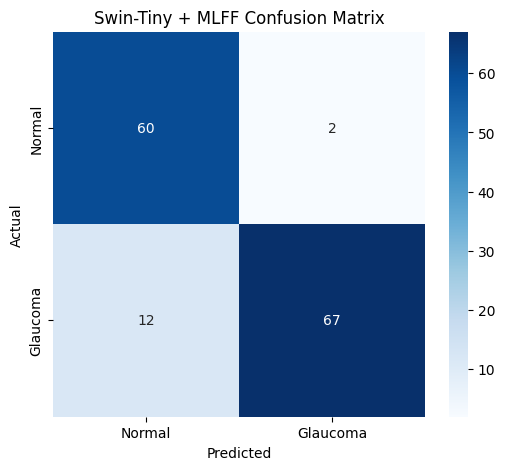

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Glaucoma"],
    yticklabels=["Normal", "Glaucoma"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Swin-Tiny + MLFF Confusion Matrix")
plt.show()

In [73]:
import torch
import torch.nn.functional as F

swin8020_model.eval()

# Take one validation image
image, label = swin8020_val_dataset[0]
image_input = image.unsqueeze(0).to(device)

with torch.no_grad():

    # Extract Swin feature levels
    features = swin8020_model.backbone(image_input)

    # Swin outputs NHWC → convert to NCHW
    f1 = features[0].permute(0, 3, 1, 2)
    f2 = features[1].permute(0, 3, 1, 2)
    f3 = features[2].permute(0, 3, 1, 2)

    # Project features
    f1 = swin8020_model.conv1(f1)
    f2 = swin8020_model.conv2(f2)
    f3 = swin8020_model.conv3(f3)

    # Resize to deepest feature-map size
    target_size = f3.shape[2:]

    f1 = F.interpolate(
        f1,
        size=target_size,
        mode="bilinear",
        align_corners=False
    )

    f2 = F.interpolate(
        f2,
        size=target_size,
        mode="bilinear",
        align_corners=False
    )

    # MLFF fusion
    fused = torch.cat([f1, f2, f3], dim=1)
    fused = swin8020_model.fusion(fused)


# Quantitative analysis
feature_maps = {
    "Level 1": f1,
    "Level 2": f2,
    "Level 3": f3,
    "Fused MLFF": fused
}

print("\nSwin-Tiny + MLFF Quantitative Feature Analysis")
print("-" * 75)

print(
    f"{'Feature':<15}"
    f"{'Mean':<12}"
    f"{'Std':<12}"
    f"{'Max':<12}"
    f"{'Active %':<12}"
)

print("-" * 75)

for name, feature in feature_maps.items():

    activation = feature.abs()

    mean_activation = activation.mean().item()
    std_activation = activation.std().item()
    max_activation = activation.max().item()

    threshold = activation.mean()

    active_percentage = (
        (activation > threshold).float().mean().item() * 100
    )

    print(
        f"{name:<15}"
        f"{mean_activation:<12.4f}"
        f"{std_activation:<12.4f}"
        f"{max_activation:<12.4f}"
        f"{active_percentage:<12.2f}"
    )


Swin-Tiny + MLFF Quantitative Feature Analysis
---------------------------------------------------------------------------
Feature        Mean        Std         Max         Active %    
---------------------------------------------------------------------------
Level 1        0.2207      0.1755      1.0393      41.41       
Level 2        1.2721      0.9080      4.4383      43.54       
Level 3        1.7527      1.2090      5.7888      47.16       
Fused MLFF     0.3673      0.5160      1.9967      34.39       


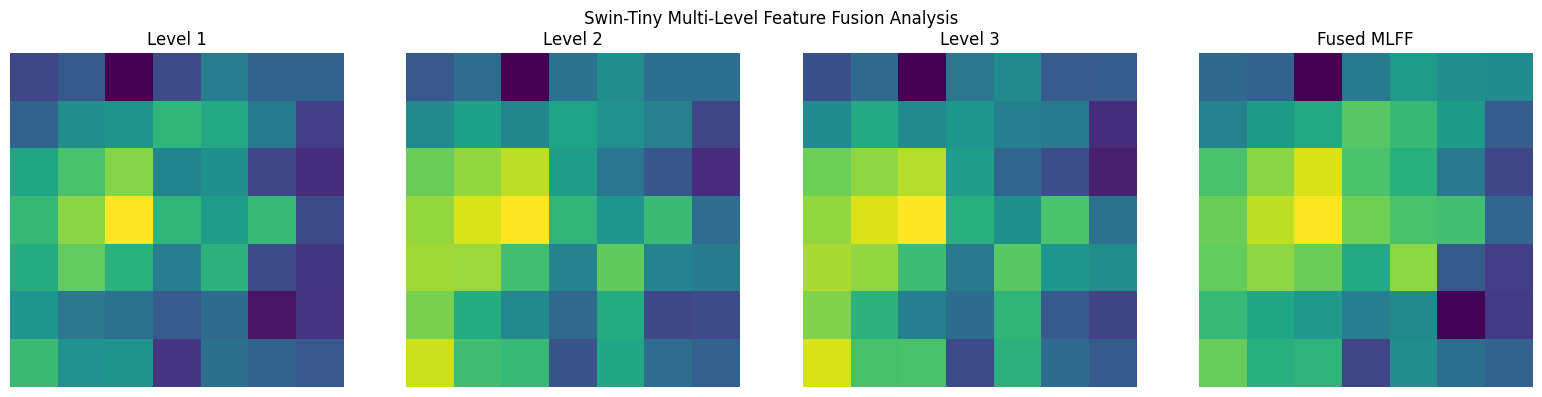

In [74]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, feature) in zip(axes, feature_maps.items()):

    activation_map = feature[0].abs().mean(dim=0).cpu().numpy()

    ax.imshow(activation_map, cmap="viridis")
    ax.set_title(name)
    ax.axis("off")

plt.suptitle("Swin-Tiny Multi-Level Feature Fusion Analysis")
plt.tight_layout()
plt.show()

In [ ]:
RESNET50 + MLFF

In [76]:
import torchvision.models as models

class ResNetMLFF(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        resnet = models.resnet50(weights=None)

        self.layer0 = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool
        )

        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        # ResNet50 feature channels
        self.conv1 = nn.Conv2d(256, 128, 1)
        self.conv2 = nn.Conv2d(512, 128, 1)
        self.conv3 = nn.Conv2d(1024, 128, 1)

        self.fusion = nn.Sequential(
            nn.Conv2d(384, 256, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.layer0(x)

        f1 = self.layer1(x)
        f2 = self.layer2(f1)
        f3 = self.layer3(f2)

        # Multi-level features
        f1 = self.conv1(f1)
        f2 = self.conv2(f2)
        f3 = self.conv3(f3)

        target_size = f3.shape[2:]

        f1 = F.interpolate(
            f1,
            size=target_size,
            mode="bilinear",
            align_corners=False
        )

        f2 = F.interpolate(
            f2,
            size=target_size,
            mode="bilinear",
            align_corners=False
        )

        # Fuse features
        fused = torch.cat([f1, f2, f3], dim=1)

        fused = self.fusion(fused)

        # Global average pooling
        fused = F.adaptive_avg_pool2d(fused, 1)

        fused = torch.flatten(fused, 1)

        return self.classifier(fused)


resnetmlff_model = ResNetMLFF(num_classes=2).to(device)

print("ResNet50 + MLFF model created successfully.")

ResNet50 + MLFF model created successfully.


In [77]:
from sklearn.model_selection import train_test_split

resnetmlff_path = "/kaggle/input/datasets/dhanushreerajangam/acrima-images-zip/Database/Images"

resnetmlff_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

resnetmlff_dataset = ACRIMADataset(
    resnetmlff_path,
    transform=resnetmlff_transform
)

resnetmlff_indices = np.arange(len(resnetmlff_dataset))
resnetmlff_labels = np.array(resnetmlff_dataset.labels)

resnetmlff_train_indices, resnetmlff_val_indices = train_test_split(
    resnetmlff_indices,
    test_size=0.20,
    random_state=42,
    stratify=resnetmlff_labels
)

print("Total images:", len(resnetmlff_dataset))
print("Training images:", len(resnetmlff_train_indices))
print("Validation images:", len(resnetmlff_val_indices))

Total images: 705
Training images: 564
Validation images: 141


In [79]:
from torch.utils.data import Subset, DataLoader

resnetmlff_train_dataset = Subset(
    resnetmlff_dataset,
    resnetmlff_train_indices
)

resnetmlff_val_dataset = Subset(
    resnetmlff_dataset,
    resnetmlff_val_indices
)

resnetmlff_train_loader = DataLoader(
    resnetmlff_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

resnetmlff_val_loader = DataLoader(
    resnetmlff_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training batches:", len(resnetmlff_train_loader))
print("Validation batches:", len(resnetmlff_val_loader))

Training batches: 18
Validation batches: 5


In [80]:
resnetmlff_criterion = nn.CrossEntropyLoss()

resnetmlff_optimizer = torch.optim.AdamW(
    resnetmlff_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

resnetmlff_epochs = 20
resnetmlff_patience = 3

print("Optimizer and training settings ready.")

Optimizer and training settings ready.


In [81]:
best_val_acc = 0
patience_counter = 0

for epoch in range(resnetmlff_epochs):

    resnetmlff_model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in resnetmlff_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        resnetmlff_optimizer.zero_grad()

        outputs = resnetmlff_model(images)
        loss = resnetmlff_criterion(outputs, labels)

        loss.backward()
        resnetmlff_optimizer.step()

        train_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)
        train_total += labels.size(0)
        train_correct += (predictions == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    # Validation
    resnetmlff_model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in resnetmlff_val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = resnetmlff_model(images)
            loss = resnetmlff_criterion(outputs, labels)

            val_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)
            val_total += labels.size(0)
            val_correct += (predictions == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{resnetmlff_epochs}] "
        f"Train Loss: {train_loss/len(resnetmlff_train_loader):.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Loss: {val_loss/len(resnetmlff_val_loader):.4f} "
        f"Val Acc: {val_acc:.2f}%"
    )

    # Save best model
    if val_acc > best_val_acc:

        best_val_acc = val_acc
        patience_counter = 0

        torch.save(
            resnetmlff_model.state_dict(),
            "/kaggle/working/best_resnetmlff_8020.pth"
        )

        print("Best model saved.")

    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= resnetmlff_patience:
        print("Early stopping.")
        break

print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

Epoch [1/20] Train Loss: 0.4982 Train Acc: 74.29% Val Loss: 0.7640 Val Acc: 56.03%
Best model saved.
Epoch [2/20] Train Loss: 0.1901 Train Acc: 92.55% Val Loss: 0.2899 Val Acc: 84.40%
Best model saved.
Epoch [3/20] Train Loss: 0.1830 Train Acc: 92.38% Val Loss: 0.1757 Val Acc: 93.62%
Best model saved.
Epoch [4/20] Train Loss: 0.1700 Train Acc: 93.09% Val Loss: 0.1686 Val Acc: 94.33%
Best model saved.
Epoch [5/20] Train Loss: 0.1971 Train Acc: 92.73% Val Loss: 0.2773 Val Acc: 85.11%
Epoch [6/20] Train Loss: 0.1222 Train Acc: 95.04% Val Loss: 0.1059 Val Acc: 95.74%
Best model saved.
Epoch [7/20] Train Loss: 0.1018 Train Acc: 97.16% Val Loss: 0.0762 Val Acc: 96.45%
Best model saved.
Epoch [8/20] Train Loss: 0.1161 Train Acc: 95.39% Val Loss: 0.1633 Val Acc: 94.33%
Epoch [9/20] Train Loss: 0.1034 Train Acc: 97.16% Val Loss: 0.0774 Val Acc: 96.45%
Epoch [10/20] Train Loss: 0.0647 Train Acc: 98.23% Val Loss: 0.0670 Val Acc: 97.16%
Best model saved.
Epoch [11/20] Train Loss: 0.0743 Train Acc:

In [82]:
resnetmlff_model.load_state_dict(
    torch.load(
        "/kaggle/working/best_resnetmlff_8020.pth",
        map_location=device
    )
)

resnetmlff_model.eval()

print("Best ResNet50 + MLFF model loaded.")

Best ResNet50 + MLFF model loaded.


In [83]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

resnetmlff_model.eval()

resnetmlff_true = []
resnetmlff_pred = []

with torch.no_grad():

    for images, labels in resnetmlff_val_loader:

        images = images.to(device)

        outputs = resnetmlff_model(images)
        predictions = torch.argmax(outputs, dim=1)

        resnetmlff_true.extend(labels.numpy())
        resnetmlff_pred.extend(predictions.cpu().numpy())

# Confusion matrix
resnetmlff_cm = confusion_matrix(
    resnetmlff_true,
    resnetmlff_pred
)

TN, FP, FN, TP = resnetmlff_cm.ravel()

# Metrics
resnetmlff_accuracy = accuracy_score(
    resnetmlff_true,
    resnetmlff_pred
)

resnetmlff_sensitivity = TP / (TP + FN)

resnetmlff_specificity = TN / (TN + FP)

resnetmlff_precision = precision_score(
    resnetmlff_true,
    resnetmlff_pred
)

resnetmlff_recall = recall_score(
    resnetmlff_true,
    resnetmlff_pred
)

resnetmlff_f1 = f1_score(
    resnetmlff_true,
    resnetmlff_pred
)

print("Confusion Matrix:")
print(resnetmlff_cm)

print(f"\nAccuracy    : {resnetmlff_accuracy * 100:.2f}%")
print(f"Sensitivity : {resnetmlff_sensitivity * 100:.2f}%")
print(f"Specificity : {resnetmlff_specificity * 100:.2f}%")
print(f"Precision   : {resnetmlff_precision * 100:.2f}%")
print(f"Recall      : {resnetmlff_recall * 100:.2f}%")
print(f"F1-Score    : {resnetmlff_f1 * 100:.2f}%")

Confusion Matrix:
[[61  1]
 [ 2 77]]

Accuracy    : 97.87%
Sensitivity : 97.47%
Specificity : 98.39%
Precision   : 98.72%
Recall      : 97.47%
F1-Score    : 98.09%


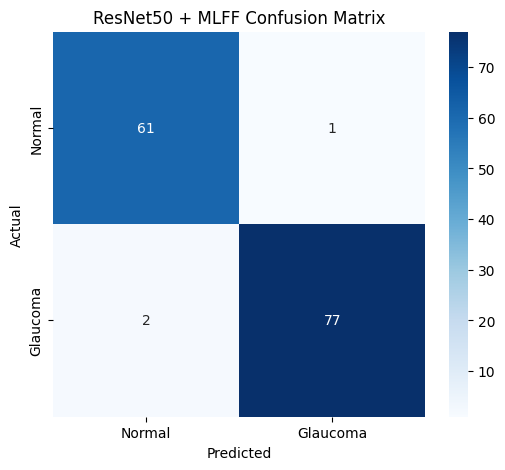

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    resnetmlff_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Glaucoma"],
    yticklabels=["Normal", "Glaucoma"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 + MLFF Confusion Matrix")
plt.show()

In [85]:
import os

print("Saved model files:")

for file in os.listdir("/kaggle/working"):
    if file.endswith(".pth"):
        print(file)

Saved model files:
best_maxvit_8020.pth
best_resnetmlff_8020.pth
best_swin_8020.pth
best_convnext_8020.pth


In [86]:
import torch
import torch.nn.functional as F

resnetmlff_model.eval()

# Take one validation image
image, label = resnetmlff_val_dataset[0]
image_input = image.unsqueeze(0).to(device)

with torch.no_grad():

    # ResNet feature extraction
    x = resnetmlff_model.layer0(image_input)

    f1 = resnetmlff_model.layer1(x)
    f2 = resnetmlff_model.layer2(f1)
    f3 = resnetmlff_model.layer3(f2)

    # Project features
    f1 = resnetmlff_model.conv1(f1)
    f2 = resnetmlff_model.conv2(f2)
    f3 = resnetmlff_model.conv3(f3)

    # Resize to deepest feature-map size
    target_size = f3.shape[2:]

    f1 = F.interpolate(
        f1,
        size=target_size,
        mode="bilinear",
        align_corners=False
    )

    f2 = F.interpolate(
        f2,
        size=target_size,
        mode="bilinear",
        align_corners=False
    )

    # MLFF fusion
    fused = torch.cat([f1, f2, f3], dim=1)
    fused = resnetmlff_model.fusion(fused)


# Store feature maps
feature_maps = {
    "Level 1": f1,
    "Level 2": f2,
    "Level 3": f3,
    "Fused MLFF": fused
}

print("\nResNet50 + MLFF Quantitative Feature Analysis")
print("-" * 75)

print(
    f"{'Feature':<15}"
    f"{'Mean':<12}"
    f"{'Std':<12}"
    f"{'Max':<12}"
    f"{'Active %':<12}"
)

print("-" * 75)

for name, feature in feature_maps.items():

    activation = feature.abs()

    mean_activation = activation.mean().item()
    std_activation = activation.std().item()
    max_activation = activation.max().item()

    threshold = activation.mean()

    active_percentage = (
        (activation > threshold).float().mean().item() * 100
    )

    print(
        f"{name:<15}"
        f"{mean_activation:<12.4f}"
        f"{std_activation:<12.4f}"
        f"{max_activation:<12.4f}"
        f"{active_percentage:<12.2f}"
    )


ResNet50 + MLFF Quantitative Feature Analysis
---------------------------------------------------------------------------
Feature        Mean        Std         Max         Active %    
---------------------------------------------------------------------------
Level 1        0.7828      0.6758      6.2469      39.94       
Level 2        0.7664      0.7385      7.9292      37.99       
Level 3        2.8446      2.4126      16.6527     40.25       
Fused MLFF     0.4886      0.7234      4.9287      34.35       


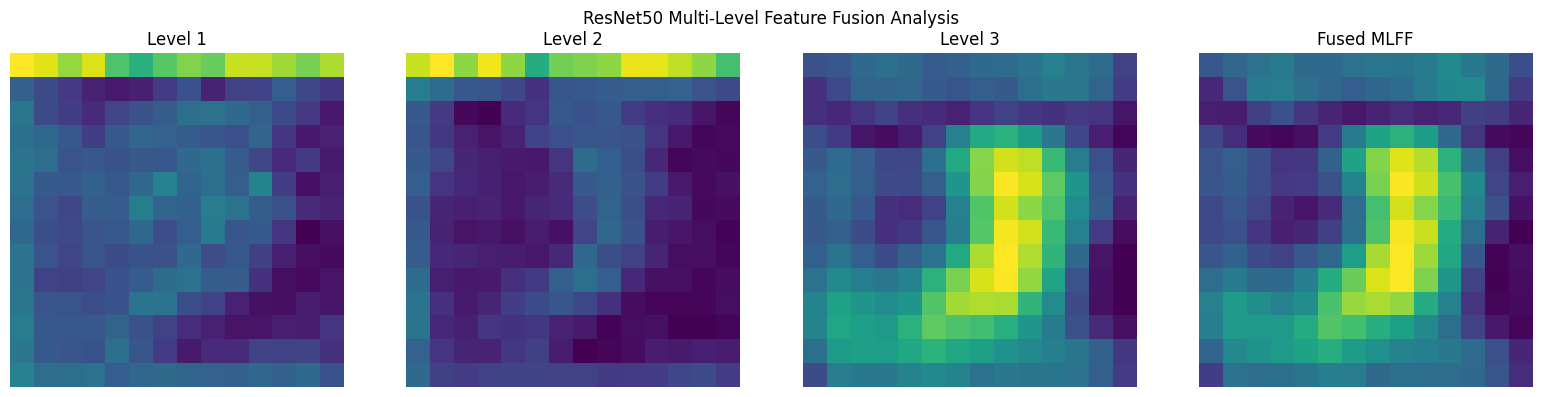

In [87]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, feature) in zip(axes, feature_maps.items()):

    activation_map = feature[0].abs().mean(dim=0).cpu().numpy()

    ax.imshow(activation_map, cmap="viridis")
    ax.set_title(name)
    ax.axis("off")

plt.suptitle("ResNet50 Multi-Level Feature Fusion Analysis")
plt.tight_layout()
plt.show()

In [99]:
torch.save(convnext8020_model.state_dict(),
           "/kaggle/working/convnext_mlff.pth")

torch.save(maxvit8020_model.state_dict(),
           "/kaggle/working/maxvit_mlff.pth")

torch.save(swin8020_model.state_dict(),
           "/kaggle/working/swin_mlff.pth")

torch.save(resnetmlff_model.state_dict(),
           "/kaggle/working/resnet50_mlff.pth")

print("All model weights saved!")
import pandas as pd

results = pd.DataFrame([
    {
        "Model": "ConvNeXt-Tiny + MLFF",
        "Level": "Level 1",
        "Mean": 0,       # replace with your printed value
        "Std": 0,
        "Max": 0,
        "Active %": 0
    }
])

results.to_csv(
    "/kaggle/working/MLFF_quantitative_analysis.csv",
    index=False
)

print("Quantitative analysis saved!")
plt.savefig(
    "/kaggle/working/convnext_mlff_features.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    "/kaggle/working/swin_mlff_features.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    "/kaggle/working/resnet50_mlff_features.png",
    dpi=300,
    bbox_inches="tight"
)

All model weights saved!
Quantitative analysis saved!


<Figure size 640x480 with 0 Axes>

In [104]:
import os

print(os.listdir("/kaggle/input/datasets/dhanushreerajangam"))

['acrima-images-zip', 'rim-one-external-validation']


In [105]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

rimone_test_path = "/kaggle/input/datasets/dhanushreerajangam/rim-one-external-validation/RIM-ONE_DL_images/RIM-ONE_DL_images/partitioned_by_hospital/test_set"

rimone_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

rimone_test_dataset = datasets.ImageFolder(
    rimone_test_path,
    transform=rimone_transform
)

rimone_test_loader = DataLoader(
    rimone_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("RIM-ONE test images:", len(rimone_test_dataset))
print("Classes:", rimone_test_dataset.class_to_idx)

RIM-ONE test images: 174
Classes: {'glaucoma': 0, 'normal': 1}


In [124]:
# Load trained ConvNeXt-Tiny + MLFF model

convnext8020_model = ConvNeXt8020Fusion(num_classes=2).to(device)

convnext8020_model.load_state_dict(
    torch.load(
        "/kaggle/working/best_convnext_8020.pth",
        map_location=device
    )
)

convnext8020_model.eval()

print("ConvNeXt-Tiny + MLFF loaded successfully!")

ConvNeXt-Tiny + MLFF loaded successfully!


In [126]:
# Get ConvNeXt predictions on RIM-ONE

convnext_preds = []

with torch.no_grad():
    for images, _ in rimone_test_loader:
        images = images.to(device)

        outputs = convnext8020_model(images)
        preds = torch.argmax(outputs, dim=1)

        convnext_preds.extend(preds.cpu().numpy())

convnext_preds = np.array(convnext_preds)

print("ConvNeXt predictions:", len(convnext_preds))
print("Prediction counts:", np.bincount(convnext_preds))

ConvNeXt predictions: 174
Prediction counts: [  2 172]


In [129]:
# Convert RIM-ONE labels to ACRIMA convention
# RIM-ONE: 0 = glaucoma, 1 = normal
# ACRIMA: 0 = normal, 1 = glaucoma

correct_labels = np.array([
    1 if x == 0 else 0
    for x in rimone_test_dataset.targets
])

# Confusion matrix
cm = confusion_matrix(correct_labels, convnext_preds)

# ACRIMA convention: 0 = Normal, 1 = Glaucoma
TN, FP, FN, TP = cm.ravel()

accuracy = (TP + TN) / (TP + TN + FP + FN)
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
precision = TP / (TP + FP)
recall = sensitivity
f1 = 2 * precision * recall / (precision + recall)

print("ConvNeXt-Tiny + MLFF — RIM-ONE External Validation")

print("\nConfusion Matrix:")
print(cm)

print(f"\nAccuracy    : {accuracy * 100:.2f}%")
print(f"Sensitivity : {sensitivity * 100:.2f}%")
print(f"Specificity : {specificity * 100:.2f}%")
print(f"Precision   : {precision * 100:.2f}%")
print(f"Recall      : {recall * 100:.2f}%")
print(f"F1 Score    : {f1 * 100:.2f}%")

ConvNeXt-Tiny + MLFF — RIM-ONE External Validation

Confusion Matrix:
[[  1 117]
 [  1  55]]

Accuracy    : 32.18%
Sensitivity : 98.21%
Specificity : 0.85%
Precision   : 31.98%
Recall      : 98.21%
F1 Score    : 48.25%


In [131]:
# Load trained MaxViT-Tiny + MLFF model

maxvit8020_model = MaxViT8020Fusion(num_classes=2).to(device)

maxvit8020_model.load_state_dict(
    torch.load(
        "/kaggle/working/best_maxvit_8020.pth",
        map_location=device
    )
)

maxvit8020_model.eval()

print("MaxViT-Tiny + MLFF loaded successfully!")

MaxViT-Tiny + MLFF loaded successfully!


In [132]:
from sklearn.metrics import confusion_matrix

maxvit_labels = []
# Get MaxViT predictions on RIM-ONE

maxvit_preds = []

with torch.no_grad():
    for images, _ in rimone_test_loader:
        images = images.to(device)

        outputs = maxvit8020_model(images)
        preds = torch.argmax(outputs, dim=1)

        maxvit_preds.extend(preds.cpu().numpy())

maxvit_preds = np.array(maxvit_preds)

# Convert RIM-ONE labels to ACRIMA convention
correct_labels = np.array([
    1 if x == 0 else 0
    for x in rimone_test_dataset.targets
])

# Confusion matrix
cm = confusion_matrix(correct_labels, maxvit_preds)

# 0 = Normal, 1 = Glaucoma
TN, FP, FN, TP = cm.ravel()

accuracy = (TP + TN) / (TP + TN + FP + FN)
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
precision = TP / (TP + FP)
recall = sensitivity
f1 = 2 * precision * recall / (precision + recall)

print("MaxViT-Tiny + MLFF — Correct RIM-ONE External Validation")

print("\nConfusion Matrix:")
print(cm)

print(f"\nAccuracy    : {accuracy * 100:.2f}%")
print(f"Sensitivity : {sensitivity * 100:.2f}%")
print(f"Specificity : {specificity * 100:.2f}%")
print(f"Precision   : {precision * 100:.2f}%")
print(f"Recall      : {recall * 100:.2f}%")
print(f"F1 Score    : {f1 * 100:.2f}%")

MaxViT-Tiny + MLFF — Correct RIM-ONE External Validation

Confusion Matrix:
[[  1 117]
 [  3  53]]

Accuracy    : 31.03%
Sensitivity : 94.64%
Specificity : 0.85%
Precision   : 31.18%
Recall      : 94.64%
F1 Score    : 46.90%


In [112]:
# Load trained Swin-Tiny + MLFF model

swin8020_model = Swin8020Fusion(num_classes=2).to(device)

swin8020_model.load_state_dict(
    torch.load(
        "/kaggle/working/best_swin_8020.pth",
        map_location=device
    )
)

swin8020_model.eval()

print("Swin-Tiny + MLFF loaded successfully!")

Swin-Tiny + MLFF loaded successfully!


In [133]:
from sklearn.metrics import confusion_matrix

swin_labels = []
# Swin-Tiny + MLFF — Correct RIM-ONE External Validation

swin_preds = []

with torch.no_grad():
    for images, _ in rimone_test_loader:
        images = images.to(device)

        outputs = swin8020_model(images)
        preds = torch.argmax(outputs, dim=1)

        swin_preds.extend(preds.cpu().numpy())

swin_preds = np.array(swin_preds)

# Convert RIM-ONE labels to ACRIMA convention
# RIM-ONE: 0 = glaucoma, 1 = normal
# Model:    0 = normal,   1 = glaucoma
correct_labels = np.array([
    1 if x == 0 else 0
    for x in rimone_test_dataset.targets
])

cm = confusion_matrix(correct_labels, swin_preds)

TN, FP, FN, TP = cm.ravel()

accuracy = (TP + TN) / (TP + TN + FP + FN)
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
precision = TP / (TP + FP)
recall = sensitivity
f1 = 2 * precision * recall / (precision + recall)

print("Swin-Tiny + MLFF — Correct RIM-ONE External Validation")

print("\nConfusion Matrix:")
print(cm)

print(f"\nAccuracy    : {accuracy * 100:.2f}%")
print(f"Sensitivity : {sensitivity * 100:.2f}%")
print(f"Specificity : {specificity * 100:.2f}%")
print(f"Precision   : {precision * 100:.2f}%")
print(f"Recall      : {recall * 100:.2f}%")
print(f"F1 Score    : {f1 * 100:.2f}%")

Swin-Tiny + MLFF — Correct RIM-ONE External Validation

Confusion Matrix:
[[  0 118]
 [  4  52]]

Accuracy    : 29.89%
Sensitivity : 92.86%
Specificity : 0.00%
Precision   : 30.59%
Recall      : 92.86%
F1 Score    : 46.02%


In [135]:
# Load trained ResNet50 + MLFF model

resnetmlff_model = ResNetMLFF(num_classes=2).to(device)

resnetmlff_model.load_state_dict(
    torch.load(
        "/kaggle/working/best_resnetmlff_8020.pth",
        map_location=device
    )
)

resnetmlff_model.eval()

print("ResNet50 + MLFF loaded successfully!")

ResNet50 + MLFF loaded successfully!


In [138]:
from sklearn.metrics import confusion_matrix

resnet_labels = []
# ResNet50 + MLFF — Correct RIM-ONE External Validation

resnet_preds = []

with torch.no_grad():
    for images, _ in rimone_test_loader:
        images = images.to(device)

        outputs = resnetmlff_model(images)
        preds = torch.argmax(outputs, dim=1)

        resnet_preds.extend(preds.cpu().numpy())

resnet_preds = np.array(resnet_preds)

# Convert RIM-ONE labels to ACRIMA convention
# RIM-ONE: 0 = glaucoma, 1 = normal
# Model:    0 = normal,   1 = glaucoma

correct_labels = np.array([
    1 if x == 0 else 0
    for x in rimone_test_dataset.targets
])

cm = confusion_matrix(correct_labels, resnet_preds)

TN, FP, FN, TP = cm.ravel()

accuracy = (TP + TN) / (TP + TN + FP + FN)
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
precision = TP / (TP + FP)
recall = sensitivity
f1 = 2 * precision * recall / (precision + recall)

print("ResNet50 + MLFF — Correct RIM-ONE External Validation")

print("\nConfusion Matrix:")
print(cm)

print(f"\nAccuracy    : {accuracy * 100:.2f}%")
print(f"Sensitivity : {sensitivity * 100:.2f}%")
print(f"Specificity : {specificity * 100:.2f}%")
print(f"Precision   : {precision * 100:.2f}%")
print(f"Recall      : {recall * 100:.2f}%")
print(f"F1 Score    : {f1 * 100:.2f}%")

ResNet50 + MLFF — Correct RIM-ONE External Validation

Confusion Matrix:
[[  2 116]
 [  3  53]]

Accuracy    : 31.61%
Sensitivity : 94.64%
Specificity : 1.69%
Precision   : 31.36%
Recall      : 94.64%
F1 Score    : 47.11%


In [140]:
import pandas as pd

rimone_results = pd.DataFrame([
    {
        "Model": "ConvNeXt-Tiny + MLFF",
        "Accuracy": 32.18,
        "Sensitivity": 98.21,
        "Specificity": 0.85,
        "Precision": 31.98,
        "Recall": 98.21,
        "F1 Score": 48.25,
        "TN": 1,
        "FP": 117,
        "FN": 1,
        "TP": 55
    },
    {
        "Model": "MaxViT-Tiny + MLFF",
        "Accuracy": 31.03,
        "Sensitivity": 94.64,
        "Specificity": 0.85,
        "Precision": 31.18,
        "Recall": 94.64,
        "F1 Score": 46.90,
        "TN": 1,
        "FP": 117,
        "FN": 3,
        "TP": 53
    },
    {
        "Model": "Swin-Tiny + MLFF",
        "Accuracy": 29.89,
        "Sensitivity": 92.86,
        "Specificity": 0.00,
        "Precision": 30.59,
        "Recall": 92.86,
        "F1 Score": 46.02,
        "TN": 0,
        "FP": 118,
        "FN": 4,
        "TP": 52
    },
    {
        "Model": "ResNet50 + MLFF",
        "Accuracy": 31.61,
        "Sensitivity": 94.64,
        "Specificity": 1.69,
        "Precision": 31.36,
        "Recall": 94.64,
        "F1 Score": 47.11,
        "TN": 2,
        "FP": 116,
        "FN": 3,
        "TP": 53
    }
])

rimone_results.to_csv(
    "/kaggle/working/RIM_ONE_external_validation_results.csv",
    index=False
)

print("Saved successfully!")
print("/kaggle/working/RIM_ONE_external_validation_results.csv")

Saved successfully!
/kaggle/working/RIM_ONE_external_validation_results.csv


In [141]:
rimone_results.to_excel(
    "/kaggle/working/RIM_ONE_external_validation_results.xlsx",
    index=False
)

print("Excel file saved!")
import numpy as np

np.save("/kaggle/working/ConvNeXt_RIM_ONE_CM.npy",
        np.array([[1,117],[1,55]]))

np.save("/kaggle/working/MaxViT_RIM_ONE_CM.npy",
        np.array([[1,117],[3,53]]))

np.save("/kaggle/working/Swin_RIM_ONE_CM.npy",
        np.array([[0,118],[4,52]]))

np.save("/kaggle/working/ResNet50_RIM_ONE_CM.npy",
        np.array([[2,116],[3,53]]))

print("All confusion matrices saved!")

Excel file saved!
All confusion matrices saved!
